# Análise de Dados - Netflix

### Para esse Business Case, será utilizado uma base de dados disponibilizada pela Netflix através do [Kaggle](https://www.kaggle.com/datasets/shivamb/netflix-shows).

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

## Carregando e Tratando os dados

In [2]:
# mesmo usando o parse a coluna date_added permaneceu como object, provavelmente possue alguns espaços em branco nestes dados...
# a conversão será feita depois

df_netflix = pd.read_csv('dataset/netflix.csv', parse_dates=['date_added'])

In [3]:
df_netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df_netflix['date_added'] = pd.to_datetime(
    df_netflix['date_added'].str.strip(),   # remove possíveis espaços extras
    format='%B %d, %Y',                     # informa explícita mente o formato desejadao: acelera muito
    errors='coerce'                         # transforma erros em NaT ao invés de quebrar
)
print(type(df_netflix['date_added']))

<class 'pandas.core.series.Series'>


In [5]:
df_netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


In [6]:
# Como boa prática....
df_netflix_trat = df_netflix.copy()

In [7]:
df_netflix_trat.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
df_netflix_trat.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [9]:
# alterando o nome das colunas
df_netflix_trat.columns = ['id', 'tipo', 'titulo', 'diretor', 'elenco', 'pais', 'dt_disponibilizacao',
       'ano_lancamento', 'classificacao', 'duracao', 'categorias', 'descricao']

In [10]:
df_netflix_trat.head()

,id,tipo,titulo,diretor,elenco,pais,dt_disponibilizacao,ano_lancamento,classificacao,duracao,categorias,descricao
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Respondendo algumas perguntas

> 1. Quantos registros e quantas colunas existem no dataset?

In [58]:
linhas, colunas = df_netflix_trat.shape
print(f"O dataset possui {linhas} linhas e {colunas} colunas.")

O dataset possui 8807 linhas e 12 colunas.


> 2. Existem colunas com valores ausentes? quais?
Sim: diretor (29.9%), elenco (9.3%), pais (9.4%), dt_disponibilizacao (0.11%), classificacao (0.04%) e duracao (0.03%) .

In [59]:
df_netflix_trat.isna().sum()

id                        0
tipo                      0
titulo                    0
diretor                2634
elenco                  825
pais                    831
dt_disponibilizacao      10
ano_lancamento            0
classificacao             4
duracao                   3
categorias                0
descricao                 0
dtype: int64

In [60]:
# em porcentagem
df_netflix_trat.isna().sum() / linhas * 100

id                      0.000000
tipo                    0.000000
titulo                  0.000000
diretor                29.908028
elenco                  9.367549
pais                    9.435676
dt_disponibilizacao     0.113546
ano_lancamento          0.000000
classificacao           0.045418
duracao                 0.034064
categorias              0.000000
descricao               0.000000
dtype: float64

> 3. Quantas séries (TV Show) e quantos filmes (Movie) estão disponíveis?
Movie: 6131 (70%)
TV Show: 2676 (30%)

In [61]:
df_netflix_trat.head()

,id,tipo,titulo,diretor,elenco,pais,dt_disponibilizacao,ano_lancamento,classificacao,duracao,categorias,descricao
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [62]:
df_netflix_trat['tipo'].value_counts()

tipo
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [63]:
# Em porcentagem
df_netflix_trat['tipo'].value_counts(normalize=True) * 100

tipo
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64

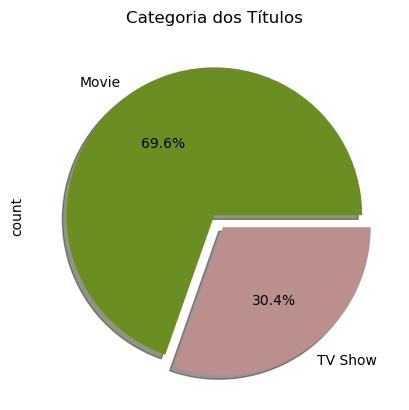

In [64]:
df_netflix_trat['tipo'].value_counts().plot(kind='pie', explode=(0, 0.1), colors=['olivedrab', 'rosybrown'], shadow=True, title='Categoria dos Títulos', autopct='%1.1f%%')
plt.show()

> 4. Quantos registros no dataset estão sem o país especificado? Liste os seus tipos (filme ou série de tv) e quantidades.

In [65]:
# Seleção dos títulos que não possuem País
df_netflix_sem_pais = df_netflix_trat.loc[df_netflix_trat['pais'].isna()]

In [66]:
df_netflix_sem_pais.shape

(831, 12)

In [67]:
df_netflix_sem_pais['tipo'].value_counts()

tipo
Movie      440
TV Show    391
Name: count, dtype: int64

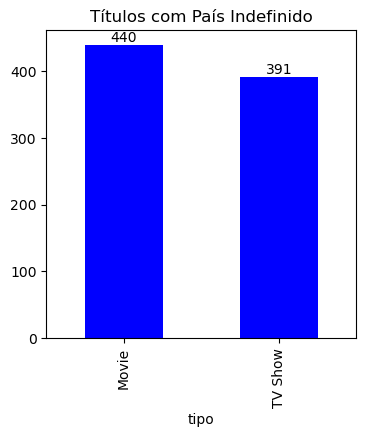

In [68]:
fig, ax = plt.subplots(figsize=(4, 4))
df_netflix_sem_pais['tipo'].value_counts().plot(kind='bar', title="Títulos com País Indefinido", color='blue')
for i, value in enumerate(df_netflix_sem_pais['tipo'].value_counts().values):
    plt.text(i, value + 5, str(value), ha='center')
plt.show()

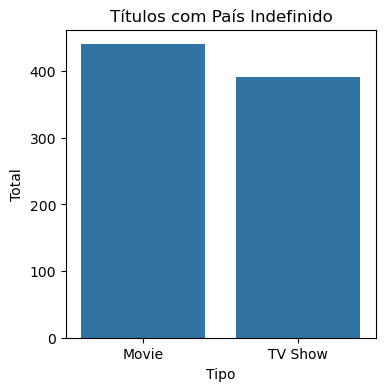

In [69]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(x=df_netflix_sem_pais['tipo'].value_counts().index, y=df_netflix_sem_pais['tipo'].value_counts().values)
plt.title("Títulos com País Indefinido")
plt.xlabel("Tipo")
plt.ylabel("Total")
plt.show()

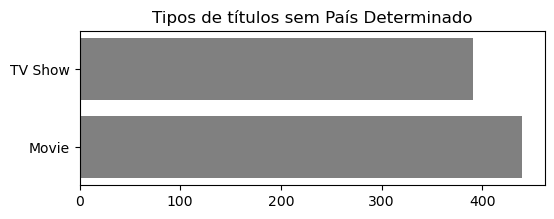

In [70]:
plt.figure(figsize=(6, 2))
plt.barh(y=df_netflix_sem_pais['tipo'].value_counts().index, width=df_netflix_sem_pais['tipo'].value_counts().values, color='grey')
plt.title('Tipos de títulos sem País Determinado')
plt.show()

> 5. Qual a data do primeiro filme disponibilizado e qual o seu título e país?
O primeiro filme foi disponibilizado em 01-01-2008. 
Seu título é: To and From New York.
País de origem: Estados Unidos.

In [71]:
df_netflix_movie = df_netflix_trat.loc[df_netflix_trat['tipo'] == 'Movie']

In [72]:
df_netflix_movie['dt_disponibilizacao'].min()

Timestamp('2008-01-01 00:00:00')

In [73]:
df_netflix_movie[df_netflix_movie['dt_disponibilizacao'] == df_netflix_movie['dt_disponibilizacao'].min()]

,id,tipo,titulo,diretor,elenco,pais,dt_disponibilizacao,ano_lancamento,classificacao,duracao,categorias,descricao
5957,s5958,Movie,To and From New York,Sorin Dan Mihalcescu,"Barbara King, Shaana Diya, John Krisiukenas, Y...",United States,2008-01-01,2006,TV-MA,81 min,"Dramas, Independent Movies, Thrillers","While covering a story in New York City, a Sea..."


> 6. Qual o diretor com maior número de títulos(filme ou série)? Qual o seu país?
Diretor: Rajiv Chilaka - País: Índia (confirmado por pesquisa no Google também)

In [74]:
df_netflix_trat['diretor'].value_counts()

diretor
Rajiv Chilaka              19
Raúl Campos, Jan Suter     18
Suhas Kadav                16
Marcus Raboy               16
Jay Karas                  14
                           ..
James Brown                 1
Ivona Juka                  1
Mu Chu                      1
Chandra Prakash Dwivedi     1
Majid Al Ansari             1
Name: count, Length: 4528, dtype: int64

In [75]:
df_netflix_trat.loc[df_netflix_trat['diretor'] == 'Rajiv Chilaka']

,id,tipo,titulo,diretor,elenco,pais,dt_disponibilizacao,ano_lancamento,classificacao,duracao,categorias,descricao
406,s407,Movie,Chhota Bheem - Neeli Pahaadi,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2013,TV-Y7,64 min,Children & Family Movies,Things get spooky when Bheem and his buddies t...
407,s408,Movie,Chhota Bheem & Ganesh,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2009,TV-Y7,68 min,Children & Family Movies,Bheem and Lord Ganesha join forces to save Dho...
408,s409,Movie,Chhota Bheem & Krishna: Mayanagari,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2011,TV-Y7,67 min,Children & Family Movies,Young lord Krishna has fallen for demoness Maa...
409,s410,Movie,Chhota Bheem & Krishna: Pataliputra- City of t...,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2010,TV-Y7,66 min,Children & Family Movies,Krishna needs Bheem’s help: The ruined city of...
410,s411,Movie,Chhota Bheem And The Broken Amulet,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",India,2021-07-22,2013,TV-Y7,64 min,Children & Family Movies,When a stranger tries to steal an amulet from ...
411,s412,Movie,Chhota Bheem And The Crown of Valhalla,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2013,TV-Y7,64 min,Children & Family Movies,To save the kingdom of Valhalla from invasion ...
412,s413,Movie,Chhota Bheem and the Incan Adventure,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2013,TV-Y7,65 min,Children & Family Movies,"When Dholakpur’s princess is kidnapped, Bheem ..."
413,s414,Movie,Chhota Bheem and The ShiNobi Secret,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2013,TV-Y7,64 min,Children & Family Movies,After learning of a samurai village under thre...
414,s415,Movie,Chhota Bheem Aur Hanuman,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2012,TV-Y7,68 min,Children & Family Movies,When two evil entities kidnap a princess in a ...
415,s416,Movie,Chhota Bheem aur Krishna,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",India,2021-07-22,2009,TV-Y7,68 min,Children & Family Movies,"Centuries after the end of a conqueror's rule,..."


In [76]:
df_netflix_trat.query("diretor == 'Rajiv Chilaka'").head()

,id,tipo,titulo,diretor,elenco,pais,dt_disponibilizacao,ano_lancamento,classificacao,duracao,categorias,descricao
406,s407,Movie,Chhota Bheem - Neeli Pahaadi,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2013,TV-Y7,64 min,Children & Family Movies,Things get spooky when Bheem and his buddies t...
407,s408,Movie,Chhota Bheem & Ganesh,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2009,TV-Y7,68 min,Children & Family Movies,Bheem and Lord Ganesha join forces to save Dho...
408,s409,Movie,Chhota Bheem & Krishna: Mayanagari,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2011,TV-Y7,67 min,Children & Family Movies,Young lord Krishna has fallen for demoness Maa...
409,s410,Movie,Chhota Bheem & Krishna: Pataliputra- City of t...,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2010,TV-Y7,66 min,Children & Family Movies,Krishna needs Bheem’s help: The ruined city of...
410,s411,Movie,Chhota Bheem And The Broken Amulet,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",India,2021-07-22,2013,TV-Y7,64 min,Children & Family Movies,When a stranger tries to steal an amulet from ...


> 7. Qual é o filme de maior duração? E o de menor duração?

- Filme de menor duração: Silent (3 min).
- Filme de maior duração: The School of Mischief (253 min).

In [77]:
df_netflix_movie = df_netflix_trat.query("tipo == 'Movie'").copy()

In [78]:
# Verificando e retornando onde há Nulo na Duração
# Analisando onde está NaN, vemos que a duração está inserida na coluna Classificação
df_netflix_movie.loc[df_netflix_movie['duracao'].isna()]

,id,tipo,titulo,diretor,elenco,pais,dt_disponibilizacao,ano_lancamento,classificacao,duracao,categorias,descricao
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [79]:
# Preenchendo os valores NaN da coluna duração com os valores da coluna Classificação
df_netflix_movie.loc[[5541,5794,5813], 'duracao'] = ['74 min', '84 min','66 min']

In [80]:
df_netflix_movie.loc[[5541,5794,5813]]

,id,tipo,titulo,diretor,elenco,pais,dt_disponibilizacao,ano_lancamento,classificacao,duracao,categorias,descricao
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,74 min,74 min,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,84 min,84 min,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,66 min,66 min,Movies,The comic puts his trademark hilarious/thought...


In [81]:
df_netflix_movie.loc[[5541,5794,5813], 'classificacao'] = np.nan

In [82]:
df_netflix_movie.loc[[5541,5794,5813]]

,id,tipo,titulo,diretor,elenco,pais,dt_disponibilizacao,ano_lancamento,classificacao,duracao,categorias,descricao
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,NaN,74 min,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,NaN,84 min,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,NaN,66 min,Movies,The comic puts his trademark hilarious/thought...


In [83]:
df_netflix_movie['duracao_min'] = df_netflix_movie['duracao'].str.replace(' min','').astype(np.int64)

In [84]:
df_netflix_movie['duracao_min'].max()

312

In [85]:
# Verificando na internet é possível ver que a duração está errada (é 1h30min)
df_netflix_movie.query("duracao_min == 312")

,id,tipo,titulo,diretor,elenco,pais,dt_disponibilizacao,ano_lancamento,classificacao,duracao,categorias,descricao,duracao_min
4253,s4254,Movie,Black Mirror: Bandersnatch,NaN,"Fionn Whitehead, Will Poulter, Craig Parkinson...",United States,2018-12-28,2018,TV-MA,312 min,"Dramas, International Movies, Sci-Fi & Fantasy","In 1984, a young programmer begins to question...",312


In [86]:
# Ordenando por duracao_min para verificar qual o próximo maior
df_netflix_movie['duracao_min'].sort_values(ascending=False)

4253    312
717     273
2491    253
2487    237
2484    233
       ... 
3535     10
1557      9
1484      8
2713      5
3777      3
Name: duracao_min, Length: 6131, dtype: int64

In [87]:
df_netflix_movie.query("duracao_min == 273")

,id,tipo,titulo,diretor,elenco,pais,dt_disponibilizacao,ano_lancamento,classificacao,duracao,categorias,descricao,duracao_min
717,s718,Movie,Headspace: Unwind Your Mind,NaN,"Andy Puddicombe, Evelyn Lewis Prieto, Ginger D...",NaN,2021-06-15,2021,TV-G,273 min,Documentaries,"Do you want to relax, meditate or sleep deeply...",273


In [88]:
# Buscando qual o filme pelo índice
# Verificando, este filme também está a duração errada
df_netflix_movie.loc[717]

id                                                                  s718
tipo                                                               Movie
titulo                                       Headspace: Unwind Your Mind
diretor                                                              NaN
elenco                 Andy Puddicombe, Evelyn Lewis Prieto, Ginger D...
pais                                                                 NaN
dt_disponibilizacao                                  2021-06-15 00:00:00
ano_lancamento                                                      2021
classificacao                                                       TV-G
duracao                                                          273 min
categorias                                                 Documentaries
descricao              Do you want to relax, meditate or sleep deeply...
duracao_min                                                          273
Name: 717, dtype: object

In [89]:
# Filme correto:
df_netflix_movie.loc[2491]

id                                                                 s2492
tipo                                                               Movie
titulo                                            The School of Mischief
diretor                                           Houssam El-Din Mustafa
elenco                 Suhair El-Babili, Adel Emam, Saeed Saleh, Youn...
pais                                                               Egypt
dt_disponibilizacao                                  2020-05-21 00:00:00
ano_lancamento                                                      1973
classificacao                                                      TV-14
duracao                                                          253 min
categorias                        Comedies, Dramas, International Movies
descricao              A high school teacher volunteers to transform ...
duracao_min                                                          253
Name: 2491, dtype: object

In [90]:
# Verificando o filme de menor duração
df_netflix_movie['duracao_min'].sort_values()

3777      3
2713      5
1484      8
1557      9
3535     10
       ... 
2484    233
2487    237
2491    253
717     273
4253    312
Name: duracao_min, Length: 6131, dtype: int64

In [91]:
# Filme correto de menor duração
df_netflix_movie.loc[3777]

id                                                                 s3778
tipo                                                               Movie
titulo                                                            Silent
diretor                                Limbert Fabian, Brandon Oldenburg
elenco                                                               NaN
pais                                                       United States
dt_disponibilizacao                                  2019-06-04 00:00:00
ano_lancamento                                                      2014
classificacao                                                       TV-Y
duracao                                                            3 min
categorias                    Children & Family Movies, Sci-Fi & Fantasy
descricao              "Silent" is an animated short film created by ...
duracao_min                                                            3
Name: 3777, dtype: object

> 8. Qual o tempo médio de duração de um filme?
- Tempo médio de duração de um filme: 99 minutos.

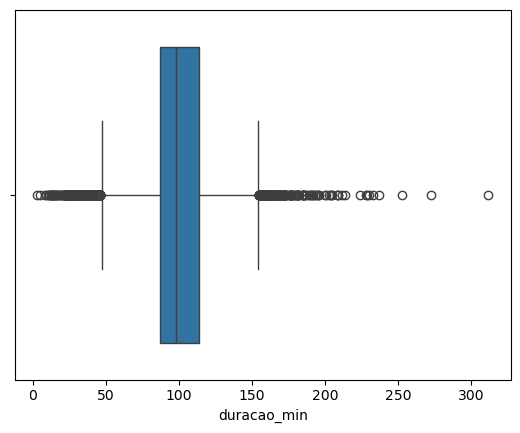

In [93]:
# Utilizando o dataset: df_netflix_movie
# Verificando a existência de outliers
sns.boxplot(x=df_netflix_movie['duracao_min'])
plt.show()

In [96]:
# Corrigindo os doi valores maiores de duração que estão errados
df_netflix_movie.loc[4253, 'duracao_min'] = 90
df_netflix_movie.loc[717, 'duracao_min'] = 15

In [101]:
df_netflix_movie.loc[4253, 'duracao'] = '90 min'
df_netflix_movie.loc[717, 'duracao'] = '15 min'

In [102]:
print(df_netflix_movie.loc[4253])
print("\n")
print(df_netflix_movie.loc[717])

id                                                                 s4254
tipo                                                               Movie
titulo                                        Black Mirror: Bandersnatch
diretor                                                              NaN
elenco                 Fionn Whitehead, Will Poulter, Craig Parkinson...
pais                                                       United States
dt_disponibilizacao                                  2018-12-28 00:00:00
ano_lancamento                                                      2018
classificacao                                                      TV-MA
duracao                                                           90 min
categorias                Dramas, International Movies, Sci-Fi & Fantasy
descricao              In 1984, a young programmer begins to question...
duracao_min                                                           90
Name: 4253, dtype: object


id                     

In [ ]:
# média e mediana bem próximas: distribuição bem próxima de uma distribuição normal (Ok informar a média)
df_netflix_movie['duracao_min'].describe().round()

count    6131.0
mean       99.0
std        28.0
min         3.0
25%        87.0
50%        98.0
75%       114.0
max       253.0
Name: duracao_min, dtype: float64

In [107]:
round(df_netflix_movie['duracao_min'].mean(),2)

np.float64(99.49)

> 9. Liste os 3 países que produzem a maior quantidadede Séries (TV Show):
- United States (760).
- United Kingdom (213).
- Japan (169).
(Resposta de acordo com o dataset utilizado!!!)

In [ ]:
df_netflix_trat.query("tipo == 'TV Show'")

In [110]:
df_netflix_trat[df_netflix_trat['tipo'] == 'TV Show']

,id,tipo,titulo,diretor,elenco,pais,dt_disponibilizacao,ano_lancamento,classificacao,duracao,categorias,descricao
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
...,...,...,...,...,...,...,...,...,...,...,...,...
8795,s8796,TV Show,Yu-Gi-Oh! Arc-V,NaN,"Mike Liscio, Emily Bauer, Billy Bob Thompson, ...","Japan, Canada",2018-05-01,2015,TV-Y7,2 Seasons,"Anime Series, Kids' TV",Now that he's discovered the Pendulum Summonin...
8796,s8797,TV Show,Yunus Emre,NaN,"Gökhan Atalay, Payidar Tüfekçioglu, Baran Akbu...",Turkey,2017-01-17,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas","During the Mongol invasions, Yunus Emre leaves..."
8797,s8798,TV Show,Zak Storm,NaN,"Michael Johnston, Jessica Gee-George, Christin...","United States, France, South Korea, Indonesia",2018-09-13,2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...
8800,s8801,TV Show,Zindagi Gulzar Hai,NaN,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,2016-12-15,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."


In [ ]:
# Por padrão, value_counts não trás a contagem para NaN
df_netflix_trat.loc[df_netflix_trat['tipo'] == 'TV Show', 'pais'].value_counts()

pais
United States                                     760
United Kingdom                                    213
Japan                                             169
South Korea                                       158
India                                              79
                                                 ... 
Ireland, Canada, United States, United Kingdom      1
Germany, United States, Italy                       1
United Kingdom, United States, Czech Republic       1
Japan, Canada                                       1
United States, France, South Korea, Indonesia       1
Name: count, Length: 196, dtype: int64

In [113]:
# Alterando o dropna em value_counts para a contagem de NaN
df_netflix_trat.loc[df_netflix_trat['tipo'] == 'TV Show', 'pais'].value_counts(dropna=False)

pais
United States                                     760
NaN                                               391
United Kingdom                                    213
Japan                                             169
South Korea                                       158
                                                 ... 
Ireland, Canada, United States, United Kingdom      1
Germany, United States, Italy                       1
United Kingdom, United States, Czech Republic       1
Japan, Canada                                       1
United States, France, South Korea, Indonesia       1
Name: count, Length: 197, dtype: int64

> 10. Em qual ano que temos o maior número de séries e filmes brasileiros disponibilizados na Netflix?
- 2020 (com 27 disponibilizações)

In [114]:
df_netflix_trat['pais'].value_counts().sort_index()

pais
, France, Algeria                                       1
, South Korea                                           1
Argentina                                              56
Argentina, Brazil, France, Poland, Germany, Denmark     1
Argentina, Chile                                        2
                                                       ..
Venezuela                                               1
Venezuela, Colombia                                     1
Vietnam                                                 7
West Germany                                            1
Zimbabwe                                                1
Name: count, Length: 748, dtype: int64

In [ ]:
# Se usarmos a pesquisa apenas por Brazil (comando abaixo), as linhas onde o Brazil tem participação serão ignoradas!!
df_netflix_trat[df_netflix_trat['pais'] == "Brazil"]

,id,tipo,titulo,diretor,elenco,pais,dt_disponibilizacao,ano_lancamento,classificacao,duracao,categorias,descricao
302,s303,Movie,City of God: 10 Years Later,"Cavi Borges, Luciano Vidigal",NaN,Brazil,2021-08-05,2013,TV-MA,69 min,"Documentaries, International Movies","A decade after the seminal Brazilian film ""Cit..."
650,s651,Movie,O Vendedor de Sonhos,Jayme Monjardim,"César Troncoso, Dan Stulbach, Thiago Mendonça,...",Brazil,2021-06-22,2016,TV-14,96 min,"Dramas, International Movies",A disillusioned psychologist tries to commit s...
783,s784,Movie,Carnaval,Leandro Neri,"Giovana Cordeiro, Gkay, Bruna Inocencio, Samya...",Brazil,2021-06-02,2021,TV-MA,95 min,"Comedies, International Movies, Music & Musicals","After a breakup, an influencer takes her frien..."
966,s967,Movie,Get the Grift,Pedro Antonio,"Marcus Majella, Samantha Schmütz, Caito Mainie...",Brazil,2021-04-28,2021,TV-MA,95 min,"Comedies, International Movies","After a botched scam, Clóvis bumps into Lohane..."
1188,s1189,Movie,Get the Goat,Vitor Brandt,"Matheus Nachtergaele, Edmilson Filho, Letícia ...",Brazil,2021-03-18,2021,TV-14,98 min,"Action & Adventure, Comedies, International Mo...",Two hapless cops find themselves in over their...
...,...,...,...,...,...,...,...,...,...,...,...,...
7818,s7819,Movie,Radical: the Controversial Saga of Dada Figuei...,Raphael Erichsen,NaN,Brazil,2017-04-12,2013,TV-MA,71 min,"Documentaries, International Movies, Sports Mo...",This film chronicles the career of surfer Dadá...
8108,s8109,Movie,Stronger Than the World,Afonso Poyart,"José Loreto, Cleo Pires, Milhem Cortaz, Jackso...",Brazil,2017-02-11,2016,NR,123 min,"Action & Adventure, Dramas, International Movies","After a tough upbringing, natural-born fighter..."
8207,s8208,TV Show,The Beginning of Life: The Series,Estela Renner,NaN,Brazil,2016-11-11,2016,TV-PG,1 Season,"Docuseries, International TV Shows, Science & ...",Using breakthroughs in technology and neurosci...
8300,s8301,Movie,The First Temptation of Christ,Rodrigo Van Der Put,"Gregorio Duvivier, Fábio Porchat, Antonio Tabe...",Brazil,2019-12-03,2019,TV-MA,46 min,"Comedies, International Movies","Jesus, who's hitting the big 3-0, brings a sur..."


In [117]:
# Seleciona onde país não é NaN E onde país possue/contém Brazil
df_netflix_trat.loc[df_netflix_trat['pais'].notna() & df_netflix_trat['pais'].str.contains('Brazil')]

,id,tipo,titulo,diretor,elenco,pais,dt_disponibilizacao,ano_lancamento,classificacao,duracao,categorias,descricao
270,s271,Movie,Beckett,Ferdinando Cito Filomarino,"John David Washington, Boyd Holbrook, Alicia V...","Italy, Brazil, Greece",2021-08-13,2021,TV-MA,110 min,Action & Adventure,An American tourist goes on the run in Greece ...
302,s303,Movie,City of God: 10 Years Later,"Cavi Borges, Luciano Vidigal",NaN,Brazil,2021-08-05,2013,TV-MA,69 min,"Documentaries, International Movies","A decade after the seminal Brazilian film ""Cit..."
650,s651,Movie,O Vendedor de Sonhos,Jayme Monjardim,"César Troncoso, Dan Stulbach, Thiago Mendonça,...",Brazil,2021-06-22,2016,TV-14,96 min,"Dramas, International Movies",A disillusioned psychologist tries to commit s...
783,s784,Movie,Carnaval,Leandro Neri,"Giovana Cordeiro, Gkay, Bruna Inocencio, Samya...",Brazil,2021-06-02,2021,TV-MA,95 min,"Comedies, International Movies, Music & Musicals","After a breakup, an influencer takes her frien..."
894,s895,Movie,Dance of the Forty One,David Pablos,"Alfonso Herrera, Emiliano Zurita, Mabel Cadena...","Mexico, Brazil",2021-05-12,2021,TV-MA,99 min,"Dramas, Independent Movies, International Movies",A gay congressman marries the Mexican presiden...
...,...,...,...,...,...,...,...,...,...,...,...,...
8207,s8208,TV Show,The Beginning of Life: The Series,Estela Renner,NaN,Brazil,2016-11-11,2016,TV-PG,1 Season,"Docuseries, International TV Shows, Science & ...",Using breakthroughs in technology and neurosci...
8300,s8301,Movie,The First Temptation of Christ,Rodrigo Van Der Put,"Gregorio Duvivier, Fábio Porchat, Antonio Tabe...",Brazil,2019-12-03,2019,TV-MA,46 min,"Comedies, International Movies","Jesus, who's hitting the big 3-0, brings a sur..."
8386,s8387,Movie,The Last Hangover,Rodrigo Van Der Put,"Fábio Porchat, Gregório Duvivier, Antonio Tabe...",Brazil,2018-12-21,2018,TV-MA,44 min,"Comedies, International Movies","In this biblical ""Hangover"" spoof, the apostle..."
8617,s8618,Movie,Trash,Stephen Daldry,"Wagner Moura, Martin Sheen, Rooney Mara, Selto...","United Kingdom, Brazil, Germany",2019-01-01,2014,R,114 min,"Dramas, Independent Movies, Thrillers",Three poor Brazilian teens find something susp...


In [118]:
df_netflix_brazil = df_netflix_trat.loc[df_netflix_trat['pais'].notna() & df_netflix_trat['pais'].str.contains('Brazil')].copy()

In [119]:
df_netflix_brazil['dt_disponibilizacao']

270    2021-08-13
302    2021-08-05
650    2021-06-22
783    2021-06-02
894    2021-05-12
          ...    
8207   2016-11-11
8300   2019-12-03
8386   2018-12-21
8617   2019-01-01
8702   2018-07-25
Name: dt_disponibilizacao, Length: 97, dtype: datetime64[ns]

In [ ]:
# Separando por anos e contando
df_netflix_brazil['dt_disponibilizacao'].dt.year.value_counts()

dt_disponibilizacao
2020    27
2019    22
2018    19
2017    16
2021    11
2016     2
Name: count, dtype: int64

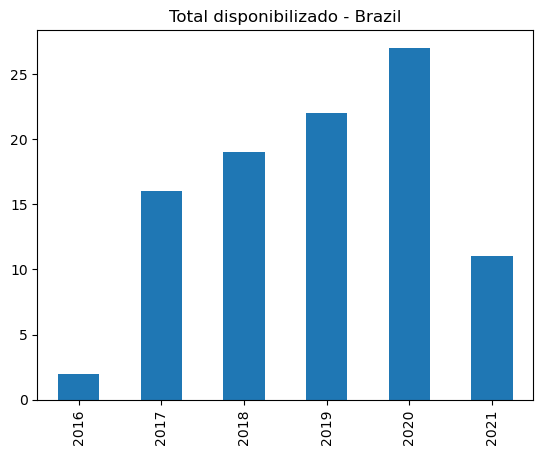

In [123]:
df_netflix_brazil['dt_disponibilizacao'].dt.year.value_counts().sort_index().plot(kind='bar')
plt.title("Total disponibilizado - Brazil")
plt.xlabel("")
plt.show()